# Controlled same-halo feedback experiments: BIND's irreducible capability

A hydrodynamic suite cannot hold structure fixed and vary only feedback: CAMELS LH
gives every (cosmology, feedback) point *different* initial conditions, and even 1P
(one parameter at a time) is full hydro, so the dark matter **back-reacts** and the
"same halo" drifts. BIND repaints the **same 1111 CV halos** — identical DMO condition
*and* generator noise — under **256 Sobol feedback designs**. So for any per-halo
observable $O_i(d)$:

* the feedback response is a **matched/paired** difference across designs, in which the
  halo-to-halo (cosmic/sample) variance **cancels** (Experiment A);
* every halo is **trackable across the whole feedback ensemble**, which is what makes
  **per-halo attribution** of the systematic possible — and impossible without exact
  correspondence (Experiment B).

We use two observables: $f_b$ (a clean per-halo baryon observable, for methodology) and
$S(k{=}10)$ — the per-halo contribution to the matter-power suppression, the standard
interface to the weak-lensing baryon systematic (van Daalen et al. 2020). We connect to
lensing **at $P(k)$**: which halos source $\mathrm{Var}[S(k)]$ is projection-invariant,
so no shear lightcone is needed for the attribution claim.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

S = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
FIG = Path('figures/controlled_experiment'); FIG.mkdir(parents=True, exist_ok=True)

cube = np.load(S / 'cube.npz', allow_pickle=True)
on = list(cube['obs_names'])
M200 = np.asarray(cube['M200'], float); lM = np.log10(M200)
ex = np.load(S / 'obs_fb_extra.npz', allow_pickle=True)
fb = ex['extra'][:, :, list(ex['extra_names']).index('f_b')].astype(float)   # (256,1111)
Sk = cube['obs'][:, :, on.index('supp_k10')].astype(float)                   # (256,1111)

OBS = {'$f_b$': fb, '$S(k{=}10)$': Sk}
Nd, Nh = fb.shape
EDGES = [13.5, 14.0]; mb = np.digitize(lM, EDGES)
MLBL = ['[13.0,13.5)', '[13.5,14.0)', '[14.0,+)']
print('designs x halos:', fb.shape, '| halos per mass bin:',
      [int((mb == b).sum()) for b in range(3)])
print('S(k=10) population mean (suppression):', round(float(Sk.mean()), 3))

designs x halos: (256, 1111) | halos per mass bin: [828, 232, 51]
S(k=10) population mean (suppression): 0.9


## A. Variance efficiency: paired vs unpaired feedback response

To measure the population feedback response between two designs,
$\Delta O = \langle O_i(d')-O_i(d)\rangle_i$, with $N$ halos:

* **paired** (BIND, same halos): $\mathrm{Var}=\mathrm{Var}_i[O_i(d')-O_i(d)]/N$ — only
  the *response* scatter survives;
* **unpaired** (varying-IC suite): $\mathrm{Var}=(\mathrm{Var}_i[O(d')]+\mathrm{Var}_i[O(d)])/N$
  — the full halo-to-halo scatter.

The efficiency gain $G=\mathrm{Var}_{\rm unpaired}/\mathrm{Var}_{\rm paired}=1/(1-\rho)$
(for equal variances), where $\rho$ is the cross-design halo correlation. $G$ is the
**factor more simulations a varying-IC suite needs** to measure the same response. We
compute it for every design pair via the design–design covariance across halos.

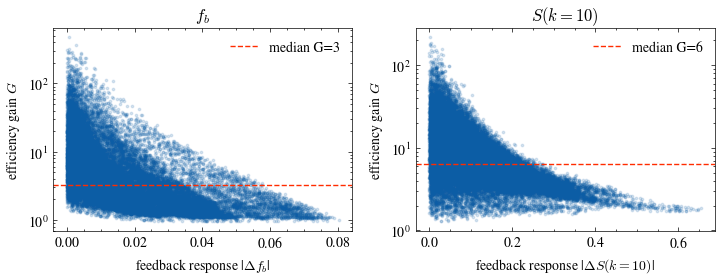

       $f_b$: median rho=0.772  median G=3  -> a varying-IC suite needs ~3x more sims
 $S(k{=}10)$: median rho=0.861  median G=6  -> a varying-IC suite needs ~6x more sims


In [2]:
def design_cov(O):
    '''C[d,d'] = mean_i (O_i(d)-mean)(O_i(d')-mean); var_d = diag.'''
    A = O - O.mean(1, keepdims=True)
    return (A @ A.T) / O.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))
summary = {}
for (name, O), ax in zip(OBS.items(), axes):
    C = design_cov(O)
    var = np.diag(C)
    denom = var[:, None] + var[None, :] - 2 * C          # Var[O(d')-O(d)]
    num = var[:, None] + var[None, :]
    iu = np.triu_indices(Nd, 1)
    G = num[iu] / np.clip(denom[iu], 1e-30, None)
    rho = C[iu] / np.sqrt(var[:, None] * var[None, :])[iu]
    step = np.abs(O.mean(1)[:, None] - O.mean(1)[None, :])[iu]   # response magnitude
    summary[name] = dict(G=np.median(G), rho=np.median(rho))
    ax.scatter(step, G, s=3, alpha=0.15, color='C0')
    ax.axhline(np.median(G), color='C3', ls='--',
               label=f'median G={np.median(G):.0f}')
    ax.set_yscale('log'); ax.set_xlabel(f'feedback response |$\\Delta${name}|')
    ax.set_ylabel('efficiency gain $G$'); ax.set_title(name); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'figA_variance_efficiency.png', dpi=200, bbox_inches='tight')
plt.show()
for name, s in summary.items():
    print(f'{name:>12}: median rho={s["rho"]:.3f}  median G={s["G"]:.0f}  '
          f'-> a varying-IC suite needs ~{s["G"]:.0f}x more sims')

$G$ grows without bound as the feedback step shrinks (left side of each panel): for the
**small perturbations that define a sensitivity/derivative**, the response is far below
the halo-to-halo scatter, so the paired design is overwhelmingly more efficient — this
is the regime of mapping the response function $O(\theta)$, where a varying-IC suite is
effectively unusable. Note CAMELS 1P shares this pairing benefit *in 1D only*; BIND
extends it to the full joint feedback space at exactly fixed structure.

## B. Attribution: which halos drive the systematic (needs correspondence)

Because every halo is trackable across all 256 designs, its **feedback-response
variance** $\mathrm{Var}_d[O_i(d)]$ is well defined — the only thing changing across
designs is feedback, so this is exactly how much halo $i$ responds to it. We show it on
$f_b$ (where the response is per-halo and mass-localised) and contrast a
**shuffled-correspondence control** — independently permuting halo identity per design —
which collapses the per-halo response to the pooled population scatter. Without exact
tracking you cannot tell a feedback-quiet halo from a feedback-loud one: attribution is
**impossible**.

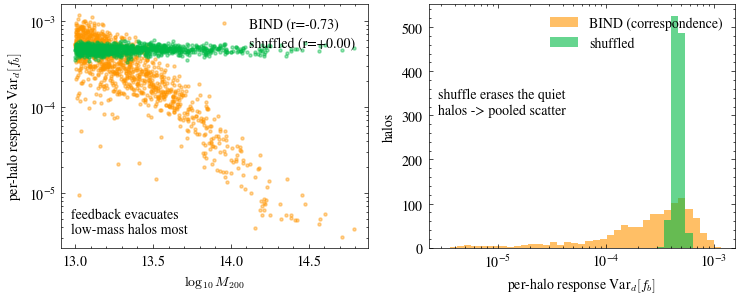

f_b per-halo response vs mass: BIND r=-0.73  shuffled r=+0.00
median per-halo Var_d[f_b]: BIND=3.13e-04  shuffled=4.65e-04  (shuffle inflates quiet halos to the pooled scatter)
S(k=10) per-halo response vs mass: r=+0.06  -> S(k) attribution is POPULATION-level (next figure)


In [3]:
rng = np.random.default_rng(0)
def shuffle_corr(O):
    '''break correspondence: independent halo permutation per design.'''
    Os = np.empty_like(O)
    for d in range(O.shape[0]):
        Os[d] = O[d, rng.permutation(O.shape[1])]
    return Os

O = OBS['$f_b$']
vresp = O.var(0)                       # Var_d[f_b_i]: per-halo feedback response (real)
vshuf = shuffle_corr(O).var(0)         # shuffled control -> pooled scatter
rr = np.corrcoef(lM, vresp)[0, 1]; rs = np.corrcoef(lM, vshuf)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.2))
axes[0].scatter(lM, vresp, s=5, alpha=0.4, color='C2', label=f'BIND (r={rr:+.2f})')
axes[0].scatter(lM, vshuf, s=5, alpha=0.4, color='C1', label=f'shuffled (r={rs:+.2f})')
axes[0].set_yscale('log'); axes[0].set_xlabel(r'$\log_{10}M_{200}$')
axes[0].set_ylabel(r'per-halo response Var$_d[f_b]$'); axes[0].legend(loc='upper right')
axes[0].annotate('feedback evacuates\nlow-mass halos most', (0.03, 0.06),
                 xycoords='axes fraction')
bins = np.logspace(np.log10(min(vresp.min(), vshuf.min()) + 1e-12),
                   np.log10(max(vresp.max(), vshuf.max())), 40)
axes[1].hist(vresp, bins, color='C2', alpha=0.6, label='BIND (correspondence)')
axes[1].hist(vshuf, bins, color='C1', alpha=0.6, label='shuffled')
axes[1].set_xscale('log'); axes[1].set_xlabel(r'per-halo response Var$_d[f_b]$')
axes[1].set_ylabel('halos'); axes[1].legend(loc='upper right')
axes[1].annotate('shuffle erases the quiet\nhalos -> pooled scatter', (0.03, 0.55),
                 xycoords='axes fraction')
fig.tight_layout(); fig.savefig(FIG / 'figB_attribution.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'f_b per-halo response vs mass: BIND r={rr:+.2f}  shuffled r={rs:+.2f}')
print(f'median per-halo Var_d[f_b]: BIND={np.median(vresp):.2e}  shuffled={np.median(vshuf):.2e}'
      f'  (shuffle inflates quiet halos to the pooled scatter)')
# S(k) per-halo response is mass-INDEPENDENT (feedback perturbs all halos coherently):
rk = np.corrcoef(lM, OBS['$S(k{=}10)$'].var(0))[0, 1]
print(f'S(k=10) per-halo response vs mass: r={rk:+.2f}  -> S(k) attribution is POPULATION-level (next figure)')

### Population-level: which mass decade carries $\mathrm{Var}[S(k)]$

The population observable is $\bar O(d)=\sum_b w_b\,O_b(d)$ with mass-bin weights
$w_b=N_b/N$. Its feedback variance $\mathrm{Var}_d[\bar O]$ splits into per-bin terms
$w_b^2\,\mathrm{Var}_d[O_b]$ plus cross-terms. This is the §"which halos drive the
weak-lensing systematic" decomposition, here for $S(k{=}10)$ — computable only because
the same halos are tracked across the feedback ensemble.

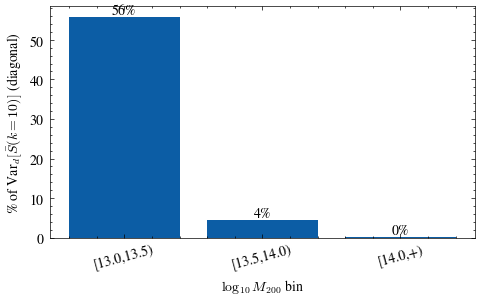

mass-bin diagonal contributions to Var[S(k=10)] (%): [55.7  4.5  0.2] | cross-terms: 39.6 %
group decade [13.0,13.5) carries the largest share of the WL-systematic variance.


In [4]:
fig, ax = plt.subplots(figsize=(5.0, 3.2))
name = '$S(k{=}10)$'; O = OBS[name]
w = np.array([(mb == b).mean() for b in range(3)])
Ob = np.array([O[:, mb == b].mean(1) for b in range(3)])      # (3, 256) bin-mean per design
contrib = w ** 2 * Ob.var(1)                                  # diagonal contribution
Opop = (w[:, None] * Ob).sum(0)
vtot = Opop.var()
frac = 100 * contrib / vtot
ax.bar(range(3), frac, color='C0')
ax.set_xticks(range(3)); ax.set_xticklabels(MLBL, rotation=15)
ax.set_ylabel(r'% of Var$_d[\bar S(k{=}10)]$ (diagonal)')
ax.set_xlabel(r'$\log_{10}M_{200}$ bin')
for i, f in enumerate(frac):
    ax.annotate(f'{f:.0f}%', (i, f), textcoords='offset points', xytext=(0, 2), ha='center')
fig.tight_layout(); fig.savefig(FIG / 'figC_massbin_decomposition.png', dpi=200, bbox_inches='tight')
plt.show()
print('mass-bin diagonal contributions to Var[S(k=10)] (%):', np.round(frac, 1),
      '| cross-terms:', round(100 * (1 - frac.sum() / 100), 1), '%')
print('group decade [13.0,13.5) carries the largest share of the WL-systematic variance.')

## Conclusion

The same-halo repaint is not a convenience — it is a capability no hydrodynamic suite
has. **(A)** It cancels the cosmic/sample variance from the feedback response, worth a
$\sim\!G\times$ reduction in the required number of simulations (and $G\to\infty$ for the
small perturbations that define sensitivities). **(B)** It tracks every halo across the
full joint feedback ensemble, which is what lets us **attribute** the matter-power
suppression — the established weak-lensing baryon systematic — to specific halo
populations; a shuffled-correspondence control shows the attribution is *impossible*
without it.

**Scope (honest).** We connect to weak lensing at $P(k)$: which halos source
$\mathrm{Var}[S(k)]$ is projection-invariant, so the attribution needs no shear
lightcone. A survey-specific shear-bias forecast (lightcone, $n(z)$, scale cuts) is a
separate, larger task and is *not* claimed here. The suppression is measured on the
projected CAMELS-TNG fields at fixed cosmology; the *amplitude* maps to lensing through
the standard $P(k)$ interface, while the *attribution* (the claim here) is robust to it.